In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

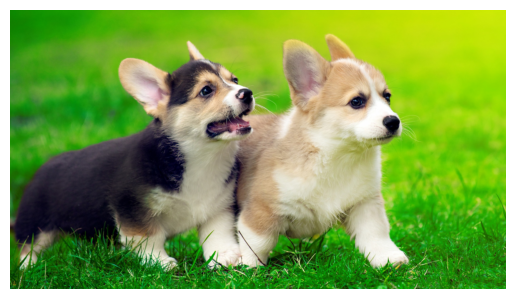

Image shape: (1080, 1920, 3)


In [2]:
path = 'images/dog.jpg'
image = cv2.imread(path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()
print(f'Image shape: {image.shape}')

In [3]:
resized_img = cv2.resize(image_rgb, (200, 200))
print(f'Resized image shape: {resized_img.shape}')

Resized image shape: (200, 200, 3)


In [4]:
pixel_values = resized_img.reshape((-1, 3))
print(f'Pixel values shape: {pixel_values.shape}')

Pixel values shape: (40000, 3)


In [5]:
pixel_values = np.float32(pixel_values)
print(f'Pixel values dtype: {pixel_values.dtype}')

Pixel values dtype: float32


# K = 3

Thuat toan da hoi tu tai lan lap thu: 14


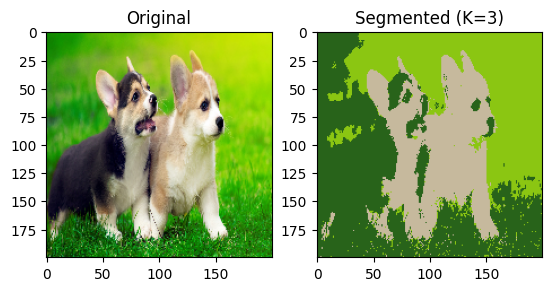

In [6]:
from model import KMeans


model = KMeans(k=3)
model.fit(pixel_values)


labels = model.predict(pixel_values)
segmented_image = model.centroids[labels].reshape(resized_img.shape).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model.k})")
plt.imshow(segmented_image)
plt.show()

In [7]:
print(f'Centroids (RGB values):\n{model.centroids}')
print(f'Centroids (RGB values) as integers:\n{model.centroids.astype(int)}')

Centroids (RGB values):
[[139.72198486 198.78735352  18.08352661]
 [ 40.20324707  99.5027771   26.94124031]
 [198.4901123  185.98902893 157.59555054]]
Centroids (RGB values) as integers:
[[139 198  18]
 [ 40  99  26]
 [198 185 157]]


In [8]:
print(f'WCSS: {model.calculate_wcss()}')
print(f'Silhouette Score: {model.calculate_silhouette_score()}')
print(f'Davies–Bouldin Index: {model.calculate_dbi()}')
print(f'Calinski–Harabasz Index: {model.calculate_calinski_harabasz()}')

WCSS: 132965574.52057101
Silhouette Score: 0.512599527835846
Davies–Bouldin Index: 0.6952135858094729
Calinski–Harabasz Index: 60420.24518477357


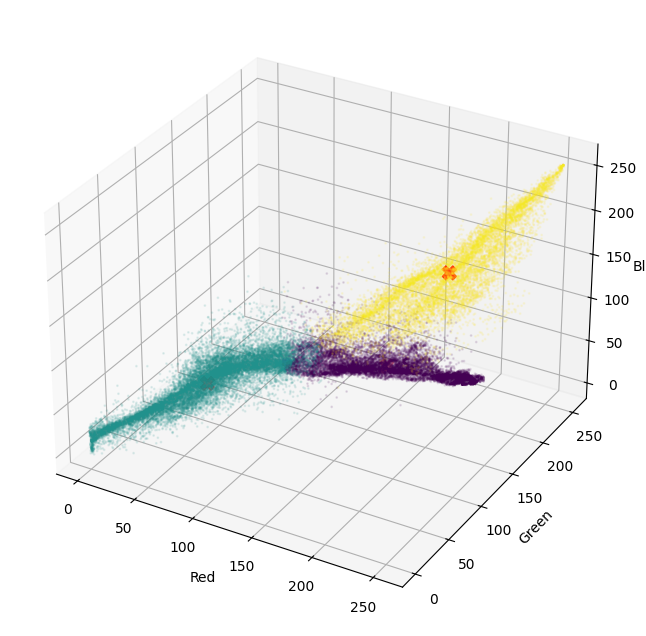

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)
        
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
                   c='red', s=100, marker='X', label='Centroids')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels, centroids=model.centroids)

# K = 5

Thuat toan da hoi tu tai lan lap thu: 38


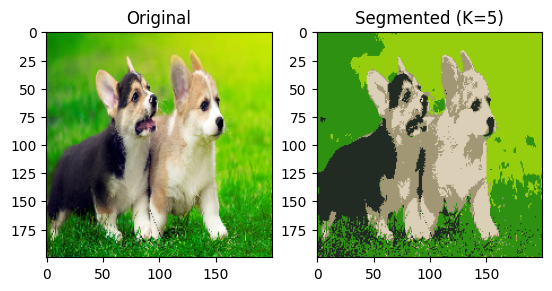

In [10]:
model1 = KMeans(k=5)
model1.fit(pixel_values)


labels = model1.predict(pixel_values)
segmented_image = model1.centroids[labels].reshape(resized_img.shape).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model1.k})")
plt.imshow(segmented_image)
plt.show()

In [11]:
print(f'Centroids (RGB values):\n{model1.centroids}')
print(f'Centroids (RGB values) as integers:\n{model1.centroids.astype(int)}')

Centroids (RGB values):
[[ 46.64390182 145.27174377  17.35736275]
 [219.66140747 208.78349304 183.51780701]
 [ 34.57653046  43.46678925  35.39154816]
 [162.81539917 151.13723755 117.13455963]
 [150.22926331 206.15100098  14.28392601]]
Centroids (RGB values) as integers:
[[ 46 145  17]
 [219 208 183]
 [ 34  43  35]
 [162 151 117]
 [150 206  14]]


In [12]:
print(f'WCSS: {model1.calculate_wcss()}')
print(f'Silhouette Score: {model1.calculate_silhouette_score()}')
print(f'Davies–Bouldin Index: {model1.calculate_dbi()}')
print(f'Calinski–Harabasz Index: {model1.calculate_calinski_harabasz()}')

WCSS: 66230046.083001465
Silhouette Score: 0.4958302676677704
Davies–Bouldin Index: 0.7069147425079698
Calinski–Harabasz Index: 70722.85181949631


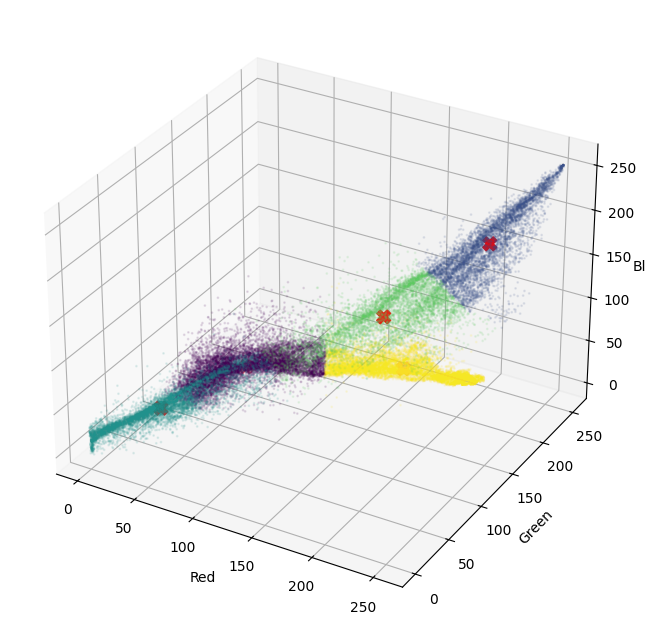

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)
        
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
                   c='red', s=100, marker='X', label='Centroids')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels, centroids=model1.centroids)

# K = 9

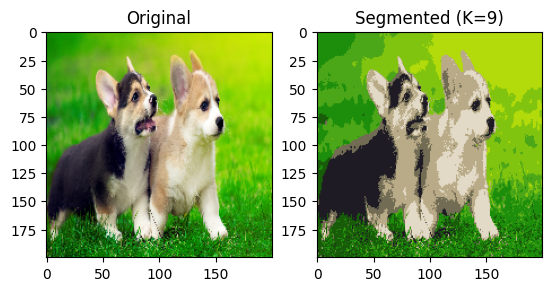

In [15]:
model2 = KMeans(k=9)
model2.fit(pixel_values)


labels = model2.predict(pixel_values)
segmented_image = model2.centroids[labels].reshape(resized_img.shape).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model2.k})")
plt.imshow(segmented_image)
plt.show()

In [17]:
print(f'Centroids (RGB values):\n{model2.centroids}')
print(f'Centroids (RGB values) as integers:\n{model2.centroids.astype(int)}')

Centroids (RGB values):
[[ 30.1058979   27.23775864  37.61056519]
 [ 75.73757935 166.01295471  24.90971947]
 [179.28643799 218.99873352  10.65547085]
 [ 29.4144249  142.69161987  11.88888931]
 [226.89320374 218.42370605 198.35818481]
 [114.66996002 108.46469116  85.49396515]
 [ 24.10350609  91.67512512   9.41802979]
 [128.39936829 196.9287262   16.8439312 ]
 [185.73242188 171.12892151 135.41729736]]
Centroids (RGB values) as integers:
[[ 30  27  37]
 [ 75 166  24]
 [179 218  10]
 [ 29 142  11]
 [226 218 198]
 [114 108  85]
 [ 24  91   9]
 [128 196  16]
 [185 171 135]]


In [19]:
print(f'WCSS: {model2.calculate_wcss()}')
print(f'Silhouette Score: {model2.calculate_silhouette_score()}')
print(f'Davies–Bouldin Index: {model2.calculate_dbi()}')
print(f'Calinski–Harabasz Index: {model2.calculate_calinski_harabasz()}')

WCSS: 33727753.54911241
Silhouette Score: 0.43031543493270874
Davies–Bouldin Index: 0.7643378682425049
Calinski–Harabasz Index: 74249.49850401869


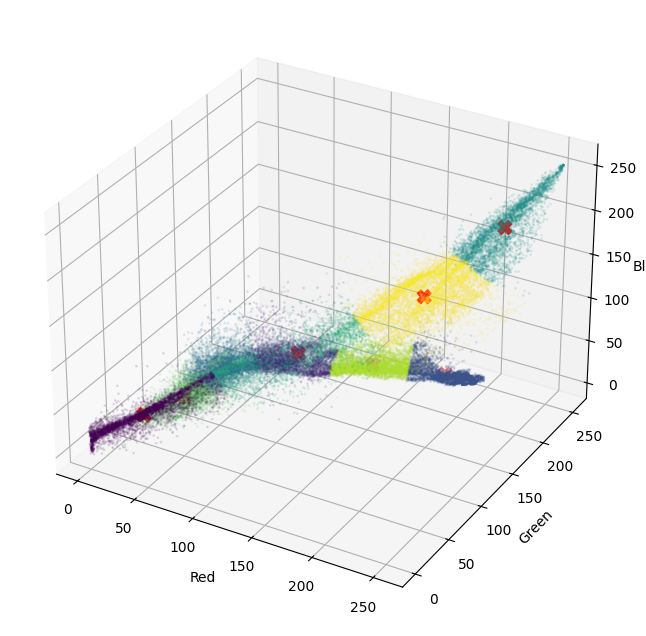

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pixels(X, labels=None, centroids=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X/255.0, s=1, alpha=0.1)
    else:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=1, alpha=0.1)
        
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
                   c='red', s=100, marker='X', label='Centroids', zorder=20)

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    plt.show()

plot_pixels(pixel_values, labels=labels, centroids=model2.centroids)